# Figure S6 — Motif-guided analog characterisation (related to Figure 5)

Six panels rendered as a single 6.5 × 8 in figure.

- **A** — Sequence alignments for all five motif families.
- **B** — MIC heatmap: 5 prototypes + 50 analogs × 20 strains; HC50/CC50 strip below.
- **C** — Calcium challenge: LPS BC displacement −Ca vs +Ca for four LPS-binding families.
- **D** — Helical wheel projections for the four bZIP analogs ranked by |ΔA|.
- **E** — NPN MaxRel at MIC by family (de novo reference + 5 motif families).
- **F** — DiSC₃(5) MaxRel at MIC by family.

In [1]:
import matplotlib as mpl, matplotlib.pyplot as plt
import numpy as np, pandas as pd, re
import pingouin as pg
from pathlib import Path
from matplotlib.patches import Rectangle, Patch
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.cm import ScalarMappable
import warnings; warnings.filterwarnings('ignore')

mpl.font_manager._load_fontmanager(try_read_cache=False)
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.size':6,'axes.titlesize':6,'axes.labelsize':6,
    'xtick.labelsize':6,'ytick.labelsize':6,'legend.fontsize':6,
    'axes.linewidth':0.5,'axes.edgecolor':'#333333',
    'xtick.color':'#333333','ytick.color':'#333333',
    'axes.labelcolor':'#222222','font.family':'sans-serif',
    'font.sans-serif':['Arial','Liberation Sans','DejaVu Sans'],
    'figure.dpi':300,'savefig.dpi':600,
    'xtick.major.width':0.5,'ytick.major.width':0.5,
    'xtick.major.size':2.5,'ytick.major.size':2.5,
    'xtick.major.pad':2,'ytick.major.pad':2,
    'axes.spines.top':False,'axes.spines.right':False,
})
DATA = Path('/home/pszymczak/code/omegamp-dashboard/data/')
OUT  = Path('/home/pszymczak/code/omegamp-dashboard/figures/')
OUT.mkdir(parents=True, exist_ok=True)

ref  = pd.read_csv(DATA/'omegamp_reference_table.csv')
mic  = pd.read_csv(DATA/'mic.csv')
hc50 = pd.read_csv(DATA/'hc50.csv')
cc50 = pd.read_csv(DATA/'cc50.csv')

_dc = lambda v: float(re.sub(r'^[<>]=?', '', str(v))) if pd.notna(v) else float('nan')
for _c in mic.columns[1:]:
    mic[_c] = mic[_c].apply(_dc)
hc50['HC50'] = hc50['HC50'].apply(_dc)
cc50['CC50'] = cc50['CC50'].apply(_dc)

npn  = pd.read_csv(DATA/'npn.csv')
disc = pd.read_csv(DATA/'disc.csv')
lps  = pd.read_csv(DATA/'lps_binding.csv')

MOTIF_FAMILIES = ['cecropin', 'LG21', 'pa4', 'sarcotoxin', 'bZIP']
PROTOTYPE_DISPLAY_NAMES = {'DBAASPS_20015': 'As-CATH4-6L', 'DBAASPS_20955': 'OP-145-TII4'}

def assign_family(r):
    if r['category'] == 'prototype':
        for f in MOTIF_FAMILIES:
            if f.lower() in r['short_name'].lower() or f == r['short_name']:
                return f
        return r['short_name']
    proto = r.get('prototype', np.nan)
    if pd.isna(proto):
        return ''
    return PROTOTYPE_DISPLAY_NAMES.get(str(proto), str(proto))

ref['family'] = ref.apply(assign_family, axis=1)

df = ref.copy()
df = df.merge(npn.rename(columns={'MaxRel': 'NPN', 'AUC': 'NPN_AUC'}), on='short_name', how='left')
df = df.merge(disc.rename(columns={'MaxRel': 'DiSC', 'AUC': 'DiSC_AUC'}), on='short_name', how='left')

mic_strains = list(mic.columns[1:])

CL = '#0072B2'; CD = '#D55E00'
LPS_COLOR = '#4A90B8'; PROTO_COLOR = '#1E3A5F'; POLYMYX_COLOR = '#888888'

def family_color(f):
    return CD if f == 'bZIP' else CL

AA_COLORS = {
    'A':'#87A7E0','I':'#87A7E0','L':'#87A7E0','M':'#87A7E0','F':'#87A7E0',
    'W':'#87A7E0','V':'#87A7E0','C':'#E787E0',
    'K':'#E87A7A','R':'#E87A7A','D':'#C256B0','E':'#C256B0',
    'N':'#85C285','Q':'#85C285','S':'#85C285','T':'#85C285',
    'G':'#F0A555','P':'#D4C540','H':'#5EC6C6','Y':'#5EC6C6',
}
MIC_CMAP = LinearSegmentedColormap.from_list('mic_rb',[
    (0.0,'#67000d'),(0.08,'#b2182b'),(0.25,'#ef8a62'),
    (0.5,'#f7f7f7'),(0.75,'#67a9cf'),(1.0,'#2166ac')])
MIC_NORM = TwoSlopeNorm(vmin=0, vcenter=32, vmax=64)
TOX_CMAP = LinearSegmentedColormap.from_list('tox_gr',[
    (0.0,'#b2182b'),(0.2,'#ef8a62'),(0.4,'#fddbc7'),
    (0.5,'#f7f7f7'),(0.6,'#a6d96a'),(0.8,'#1a9641'),(1.0,'#006837')])
TOX_NORM = TwoSlopeNorm(vmin=0.1, vcenter=1, vmax=128)

STRAIN_LABELS = {
    'A. baumannii ATCC 19606 (-)':                'A. baumannii ATCC 19606',
    'A. baumannii ATCC BAA-1605 (-) - CGTPACCIMRA':'A. baumannii ATCC BAA-1605',
    'E. cloacae ATCC 13047 (-)':                  'E. cloacae ATCC 13047',
    'E. coli ATCC 11775 (-)':                     'E. coli ATCC 11775',
    'E. coli AIC221 (-)':                         'E. coli AIC221',
    'E. coli AIC222 - CRE (-)':                   'E. coli AIC222',
    'E. coli ATCC BAA-3170 (-) - CRE':            'E. coli ATCC BAA-3170',
    'K. pneumoniae ATCC 13883 (-)':               'K. pneumoniae ATCC 13883',
    'K. pneumoniae ATCC BAA-2342 (-) - EIRK':     'K. pneumoniae ATCC BAA-2342',
    'P. aeruginosa PAO1 (-)':                     'P. aeruginosa PAO1',
    'P. aeruginosa PA14 (-)':                     'P. aeruginosa PA14',
    'P. aeruginosa ATCC BAA-3197 (-) - FBCRP':    'P. aeruginosa ATCC BAA-3197',
    'S. enterica ATCC 9150 (-)':                  'S. enterica ATCC 9150',
    'S. enterica Typhimurtium ATCC 700720':        'S. enterica Typhi.',
    'B. subtilis ATCC 23857 (+)':                 'B. subtilis ATCC 23857',
    'S. aureus ATCC 12600 (+)':                   'S. aureus ATCC 12600',
    'S. aureus ATCC BAA-1556 - MRSA (+)':         'S. aureus ATCC BAA-1556',
    'E. faecalis ATCC 700802 - VRE (+)':          'E. faecalis ATCC 700802',
    'E. faecium ATCC 700221 - VRE (+)':           'E. faecium ATCC 700221',
    'E. coli K-12 BW25113 (-)':                   'E. coli K-12',
}
STRAIN_MDR = {s: any(t in s for t in ['CRAB','CRE','ESBL','EIRK','FBCR','FQR','MRSA','VRE','CGTPA'])
              for s in mic_strains}
STRAIN_GRAM = {s: ('+' if '(+)' in s else '-') for s in mic_strains}
_ecoli = [s for s in mic_strains if 'coli' in s.lower()]
strain_order = []
for s in mic_strains:
    if s in _ecoli: continue
    strain_order.append(s)
    if 'cloacae' in s.lower(): strain_order.extend(_ecoli)
if not any('coli' in s.lower() for s in strain_order): strain_order.extend(_ecoli)

LEADS_SHORT = {
    'Ω-MT-cecropin-1':'Ω-C-1','Ω-MT-cecropin-4':'Ω-C-4',
    'Ω-MT-pa4-1':'Ω-P-1','Ω-MT-sarcotoxin-4':'Ω-S-4','Ω-MT-bZIP-8':'Ω-Z-8',
}
LS = set(LEADS_SHORT.keys())
LEAD_INDICES = {'cecropin':{1,4},'pa4':{1},'sarcotoxin':{4},'bZIP':{8},'LG21':set()}
FAM_LETTER = {'cecropin':'C','LG21':'L','pa4':'P','sarcotoxin':'S','bZIP':'Z'}
LEAD_OFFSETS_F = {
    'Ω-MT-cecropin-1':(8,10),'Ω-MT-cecropin-4':(8,16),
    'Ω-MT-pa4-1':(8,12),'Ω-MT-sarcotoxin-4':(8,12),'Ω-MT-bZIP-8':(8,-12),
}
LEAD_OFFSETS_G = {
    'Ω-MT-cecropin-1':(8,12),'Ω-MT-cecropin-4':(8,10),
    'Ω-MT-pa4-1':(8,14),'Ω-MT-sarcotoxin-4':(8,-14),'Ω-MT-bZIP-8':(8,12),
}
LPS_FAM_COLORS = {'cecropin':'#0072B2','LG21':'#009E73','pa4':'#CC79A7','sarcotoxin':'#E69F00'}
LPS_FAMS_ORDER = ['cecropin','LG21','pa4','sarcotoxin']
LPS_LEAD_MAP   = {
    'cecropin':   [('Ω-MT-cecropin-1',  'Ω-C-1', (8,  8)),
                   ('Ω-MT-cecropin-4',  'Ω-C-4', (8, -8))],
    'pa4':        [('Ω-MT-pa4-1',       'Ω-P-1', (8,  8))],
    'sarcotoxin': [('Ω-MT-sarcotoxin-4','Ω-S-4', (8,  8))],
}

def kw_stats(groups):
    """Kruskal-Wallis H-stat; ε² = H / (n−1) (Tomczak & Tomczak 2014)."""
    vals = np.concatenate(groups)
    grps = np.repeat(np.arange(len(groups)), [len(g) for g in groups]).astype(str)
    res  = pg.kruskal(data=pd.DataFrame({'val': vals, 'group': grps}),
                      dv='val', between='group')
    H = float(res['H'].iloc[0])
    p = float(res['p_unc'].iloc[0])
    return p, max(0.0, H / (len(vals) - 1))

def kw_label(ax, groups):
    p, eta2 = kw_stats(groups)
    ax.text(0.5, 1.02, f'KW $p$ = {p:.1e}, $\\varepsilon^2$ = {eta2:.2f}',
            transform=ax.transAxes, fontsize=6, ha='center', va='bottom',
            color='#555', fontweight='bold')

def mw_stats(a, b):
    res = pg.mwu(np.asarray(a, dtype=float), np.asarray(b, dtype=float))
    return float(res['p_val'].iloc[0]), float(res['RBC'].iloc[0])

def annotate_lead(ax, x, y, label, offset=(10, 8)):
    ax.annotate(label, (x, y), fontsize=6, ha='left', va='center', color='black',
                xytext=offset, textcoords='offset points',
                arrowprops=dict(arrowstyle='-', color='#555', lw=0.4), zorder=10,
                annotation_clip=False)

# ── Panel A: Sequence alignments ───────────────────────────────────────────────
def get_family_sequences(template_name):
    tpl = ref[ref['short_name'] == template_name].iloc[0]
    labels = [template_name]; seqs = [tpl['sequence']]; bolds = [True]
    leads = LEAD_INDICES.get(template_name, set())
    analogs = ref[(ref['family'] == template_name) & (ref['category'] == 'analog')].copy()
    analogs['idx'] = analogs['short_name'].str.extract(r'-(\d+)$').astype(int)
    for _, r in analogs.sort_values('idx').iterrows():
        i = int(r['idx'])
        labels.append(f'Ω-{i}'); seqs.append(r['sequence']); bolds.append(i in leads)
    return labels, seqs, bolds

def draw_alignment(ax, labels, seqs, bolds, title, fontsize=6):
    n = len(seqs); max_len = max(len(s) for s in seqs); template = seqs[0]
    for i, (lab, seq) in enumerate(zip(labels, seqs)):
        y = n - 1 - i; wt = 'bold' if bolds[i] else 'normal'
        ax.text(-0.5, y+0.5, lab, ha='right', va='center', fontsize=fontsize,
                family='monospace', fontweight=wt)
        for j, aa in enumerate(seq):
            col = (AA_COLORS.get(aa, 'white') if i == 0
                   else (AA_COLORS.get(aa, 'white') if j < len(template) and aa == template[j] else 'white'))
            ax.add_patch(Rectangle((j, y), 1, 1, facecolor=col, edgecolor='none', linewidth=0))
            ax.text(j+0.5, y+0.5, aa, ha='center', va='center', fontsize=fontsize,
                    family='monospace', color='black', fontweight=wt)
    ax.text(max_len/2, n+0.35, title, ha='center', va='bottom', fontsize=fontsize+1, fontweight='bold')
    ax.set_xlim(-7.0, max_len+0.3); ax.set_ylim(-0.1, n+0.8)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)

# ── Panel B: Motif MIC heatmap ─────────────────────────────────────────────────
_GAP = '__gap__'

def _motif_pep_list():
    names, labels, colors, is_bold = [], [], [], []
    for fi, fam in enumerate(MOTIF_FAMILIES):
        if fi > 0:
            names.append(_GAP); labels.append(''); colors.append('none'); is_bold.append(False)
        proto_rows = ref[(ref['family'] == fam) & (ref['category'] == 'prototype')]
        if len(proto_rows):
            names.append(proto_rows.iloc[0]['short_name']); labels.append(fam)
            colors.append(family_color(fam)); is_bold.append(True)
        analogs = ref[(ref['family'] == fam) & (ref['category'] == 'analog')].copy()
        analogs['idx'] = analogs['short_name'].str.extract(r'-(\d+)$').astype(int)
        analogs = analogs.sort_values('idx')
        letter = FAM_LETTER[fam]
        for _, r in analogs.iterrows():
            num = r['short_name'].split('-')[-1]
            names.append(r['short_name']); labels.append(f'Ω-{letter}-{num}')
            colors.append(family_color(fam)); is_bold.append(r['short_name'] in LS)
    return names, labels, colors, is_bold

def draw_motif_heatmap(ax_mic, ax_tox, cax_mic, cax_tox):
    names, labels, colors, is_bold = _motif_pep_list()
    n_p = len(names); n_s = len(strain_order)
    gaps = [j for j, nm in enumerate(names) if nm == _GAP]
    mic_d = mic.set_index('short_name')
    hc_d = hc50.set_index('short_name')['HC50'].clip(0.1, 128).to_dict()
    cc_d = cc50.set_index('short_name')['CC50'].clip(0.1, 128).to_dict()

    hm = np.full((n_s, n_p), 128.0)
    for j, nm in enumerate(names):
        if nm == _GAP or nm not in mic_d.index: continue
        row = mic_d.loc[nm]
        for i, s in enumerate(strain_order):
            v = row.get(s, np.nan)
            if pd.notna(v): hm[i, j] = float(v)
    im = ax_mic.imshow(hm.clip(0, 64), aspect='auto', cmap=MIC_CMAP, norm=MIC_NORM, interpolation='nearest')
    for j in gaps:
        ax_mic.add_patch(Rectangle((j-0.5, -0.5), 1, n_s, facecolor='white', edgecolor='none', zorder=3))
    ax_mic.set_yticks(range(n_s)); ax_mic.tick_params(axis='y', pad=2, length=0)
    yl = ax_mic.set_yticklabels([STRAIN_LABELS.get(s, s) for s in strain_order], fontsize=6)
    for yi, s in enumerate(strain_order):
        yl[yi].set_color('#DC2626' if STRAIN_GRAM[s] == '+' else '#2563EB')
        yl[yi].set_fontstyle('italic')
        if STRAIN_MDR[s]: yl[yi].set_fontweight('bold')
    ax_mic.set_xticks([]); ax_mic.set_xlim(-0.5, n_p-0.5)

    tox = np.full((2, n_p), np.nan)
    for j, nm in enumerate(names):
        if nm == _GAP: continue
        tox[0, j] = hc_d.get(nm, np.nan); tox[1, j] = cc_d.get(nm, np.nan)
    tm = np.ma.array(tox, mask=np.isnan(tox)); tc = TOX_CMAP.copy(); tc.set_bad('#dddddd')
    ax_tox.imshow(tm, aspect='auto', cmap=tc, norm=TOX_NORM, interpolation='nearest')
    for j in gaps:
        ax_tox.add_patch(Rectangle((j-0.5, -0.5), 1, 2, facecolor='white', edgecolor='none', zorder=3))
    ax_tox.set_yticks([0, 1]); ax_tox.set_yticklabels(['HC$_{50}$', 'CC$_{50}$'], fontsize=6, fontweight='bold')
    ax_tox.tick_params(axis='y', pad=2, length=0)
    ax_tox.set_xticks(range(n_p)); ax_tox.tick_params(axis='x', pad=5, length=0)
    xl = ax_tox.set_xticklabels(labels, rotation=90, ha='right', fontsize=6, family='monospace')
    for xi, (c, b) in enumerate(zip(colors, is_bold)):
        xl[xi].set_color(c)
        if b: xl[xi].set_fontweight('bold')
    ax_tox.set_xlim(-0.5, n_p-0.5)

    cb = plt.colorbar(im, cax=cax_mic)
    cb.ax.set_title('MIC\n(μM)', fontsize=6, pad=4, loc='center')
    cb.set_ticks([0, 1, 8, 16, 32, 64]); cb.ax.minorticks_off(); cb.ax.tick_params(labelsize=6); cb.outline.set_visible(False)
    cb2 = plt.colorbar(ScalarMappable(norm=TOX_NORM, cmap=TOX_CMAP), cax=cax_tox)
    cb2.ax.set_title('HC$_{50}$/CC$_{50}$\n(μM)', fontsize=6, pad=4, loc='center')
    cb2.set_ticks([0.1, 1, 10, 100]); cb2.set_ticklabels(['0.1', '1', '10', '≥128'])
    cb2.ax.minorticks_off(); cb2.ax.tick_params(labelsize=6); cb2.outline.set_visible(False)

# ── Panel C: Calcium challenge — Δ strip chart ─────────────────────────────────
def draw_lps_delta(ax, conc=32):
    sub = lps[lps['concentration'] == conc]
    sm  = sub.groupby(['short_name', 'calcium'])['BC_displacement'].mean().reset_index()
    pv  = sm.pivot(index='short_name', columns='calcium', values='BC_displacement').reset_index()
    pv.columns.name = None
    if 'yes' not in pv.columns or 'no' not in pv.columns:
        return
    pv = pv.dropna(subset=['yes', 'no'])
    pv['delta'] = pv['yes'] - pv['no']
    fam_map   = lps[['short_name', 'family']].drop_duplicates('short_name').set_index('short_name')['family'].to_dict()
    cat_local = ref.set_index('short_name')['category'].to_dict()
    pv['family']   = pv['short_name'].map(fam_map)
    pv['category'] = pv['short_name'].map(cat_local)

    pmx = pv[pv['short_name'] == 'Polymyxin B'].copy()
    pv  = pv[(pv['family'].isin(LPS_FAMS_ORDER)) & (pv['short_name'] != 'Polymyxin B')]

    ax.axhline(0, color='#888', ls='--', lw=0.6, zorder=1)
    rng = np.random.RandomState(42)
    for xi, fam in enumerate(LPS_FAMS_ORDER):
        lead_map = {nm: (lbl, off) for nm, lbl, off in LPS_LEAD_MAP.get(fam, [])}
        for _, r in pv[pv['family'] == fam].iterrows():
            is_proto = r['category'] == 'prototype'
            is_lead  = r['short_name'] in lead_map
            jitter = rng.uniform(-0.18, 0.18)
            if is_proto:
                mk, sz, ec, z = 'D', 28, 'white', 8
            elif is_lead:
                mk, sz, ec, z = 'o', 18, 'black', 7
            else:
                mk, sz, ec, z = 'o', 8, 'white', 5
            ax.scatter(xi+jitter, r['delta'], marker=mk, c=CL, s=sz,
                       edgecolors=ec, lw=0.4, zorder=z)
            if is_lead:
                lbl, off = lead_map[r['short_name']]
                annotate_lead(ax, xi+jitter, r['delta'], lbl, off)

    xi_pmx = len(LPS_FAMS_ORDER)
    for _, r in pmx.iterrows():
        jitter = rng.uniform(-0.18, 0.18)
        ax.scatter(xi_pmx+jitter, r['delta'], marker='D', c=POLYMYX_COLOR, s=28,
                   edgecolors='white', lw=0.4, zorder=8)

    all_xlabels = [f'$\\it{{{f}}}$' for f in LPS_FAMS_ORDER] + ['Pmx B']
    ax.set_xticks(range(len(all_xlabels)))
    ax.set_xticklabels(all_xlabels, fontsize=6)
    ax.set_ylabel('Δ BC displ.\n(+Ca$^{2+}$ − −Ca$^{2+}$, %)', fontsize=6)
    ax.text(0.02, 0.90, 'Ca$^{2+}$-tolerant', transform=ax.transAxes, fontsize=6,
            ha='left', va='top', color='#555', style='italic')
    ax.text(0.02, 0.08, 'Ca$^{2+}$-suppressed', transform=ax.transAxes, fontsize=6,
            ha='left', va='bottom', color='#555', style='italic')
    ax.scatter([], [], marker='D', c=CL, edgecolors='white', lw=0.4, s=18, label='Prototype')
    ax.scatter([], [], marker='o', c=CL, edgecolors='black', lw=0.4, s=12, label='Lead')
    ax.scatter([], [], marker='o', c=CL, edgecolors='white', lw=0.4, s=7,  label='Analog')
    ax.legend(fontsize=6, frameon=False, loc='upper right', handletextpad=0.3,
              borderpad=0, handlelength=0.8, ncol=3, columnspacing=0.8)
    ax.tick_params(length=2)
    for side in ('top', 'right'): ax.spines[side].set_visible(False)

# ── Panel D: bZIP helical wheels ───────────────────────────────────────────────
_HW_CATIONIC    = set('KRH')
_HW_ANIONIC     = set('DE')
_HW_HYDROPHOBIC = set('LIVAFWMYG')

WHEEL_COLORS = {
    'cationic':    '#2E86C1',
    'anionic':     '#C0392B',
    'hydrophobic': '#F1C40F',
    'polar':       '#BDC3C7',
}

def _hw_classify(aa):
    if aa in _HW_CATIONIC:    return 'cationic'
    if aa in _HW_ANIONIC:     return 'anionic'
    if aa in _HW_HYDROPHOBIC: return 'hydrophobic'
    return 'polar'

def helical_wheel(seq, name, ax, n_show=18):
    """Project the first n_show residues onto a helical wheel (100°/residue)."""
    angle_step = 100.0
    seq_show = seq[:n_show]
    positions = {}
    for i, aa in enumerate(seq_show):
        theta_deg = (90 - i * angle_step) % 360
        key = round(theta_deg, 1)
        positions.setdefault(key, []).append((aa, i + 1))
    for angle_deg, residues in positions.items():
        theta = np.radians(angle_deg)
        for j, (aa, _) in enumerate(residues):
            r = 1.0 + j * 0.42
            x = r * np.cos(theta)
            y = r * np.sin(theta)
            ax.add_patch(plt.Circle((x, y), 0.24, color=WHEEL_COLORS[_hw_classify(aa)],
                                    ec='black', lw=0.4, zorder=3))
            ax.text(x, y, aa, ha='center', va='center',
                    fontsize=6, fontweight='bold', zorder=4)
    for i in range(len(seq_show) - 1):
        theta_a = np.radians((90 - i * angle_step) % 360)
        theta_b = np.radians((90 - (i + 1) * angle_step) % 360)
        ax.plot([np.cos(theta_a), np.cos(theta_b)],
                [np.sin(theta_a), np.sin(theta_b)],
                color='#bbb', lw=0.3, zorder=1)
    ax.set_xlim(-1.7, 1.7)
    ax.set_ylim(-1.9, 1.7)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.text(0, -1.85, name, ha='center', va='top', fontsize=6.5, fontweight='normal')

BZIP_WHEEL_PANELS = [
    ('GFLLKKSVAKLGKVNTALRNLVSKLTHEVR', 'Ω-MT-bZIP-9'),
    ('GFRLLRKVASLIASNLKLLKGVSKLLSKVR', 'Ω-MT-bZIP-2'),
    ('MEKLSSQVLRLRVYNKLLNRYVRKLSRRVK', 'Ω-MT-bZIP-1'),
    ('RRVLLRAVSRLATANDGLYGFVRRLARKVK',  'Ω-MT-bZIP-3'),
]

# ── Panels E/F: at-MIC dotplots ────────────────────────────────────────────────
def draw_atmic_dotplot(ax, metric, offsets, ylabel_text):
    analogs = df[(df['family'].isin(MOTIF_FAMILIES)) & (df['category'] == 'analog')].copy()
    de_novo = df[df['category'] == 'de_novo'].copy()
    de_novo_vals = de_novo[metric].dropna()
    jt0 = np.random.RandomState(99 + (0 if metric == 'NPN' else 1)).normal(0, 0.08, len(de_novo_vals))
    ax.scatter(np.zeros(len(de_novo_vals)) + jt0, de_novo_vals.values,
               c='#aaaaaa', s=4, alpha=0.4, edgecolors='#888', lw=0.1, zorder=2)
    for j_idx, fam in enumerate(MOTIF_FAMILIES):
        xi = j_idx + 1; c = family_color(fam)
        fam_analogs = analogs[analogs['family'] == fam]
        proto_rows  = df[(df['family'] == fam) & (df['category'] == 'prototype')]
        jt = np.random.RandomState(j_idx*7 + (0 if metric == 'NPN' else 1)).normal(0, 0.1, len(fam_analogs))
        for k, (_, r) in enumerate(fam_analogs.iterrows()):
            if pd.isna(r[metric]): continue
            if r['short_name'] in LS:
                ax.scatter(xi+jt[k], r[metric], c=c, s=10, edgecolors='black', lw=0.5, zorder=5)
                annotate_lead(ax, xi+jt[k], r[metric], LEADS_SHORT[r['short_name']],
                              offsets.get(r['short_name'], (6, 8)))
            else:
                ax.scatter(xi+jt[k], r[metric], c=c, s=7, alpha=0.7, edgecolors='#555', lw=0.2, zorder=3)
        if len(proto_rows) > 0:
            pv = proto_rows[metric].dropna().values
            if len(pv) > 0:
                ax.scatter([xi], pv, marker='D', c=c, edgecolors='#333', lw=0.6, s=18, zorder=5)
    ax.axhline(de_novo_vals.median(), color='#ddd', ls=':', lw=0.5, zorder=1)
    ax.set_xticks(range(6))
    ax.set_xticklabels(['de novo'] + [f'$\\it{{{f}}}$' for f in MOTIF_FAMILIES], fontsize=6)
    ax.get_xticklabels()[0].set_style('italic')
    ax.set_ylabel(ylabel_text, fontsize=6)
    groups = [analogs[analogs['family'] == f][metric].dropna().values
              for f in MOTIF_FAMILIES
              if len(analogs[analogs['family'] == f][metric].dropna()) > 0]
    if len(groups) >= 2:
        kw_label(ax, groups)

print('Setup complete.')

Setup complete.


  export box: 6.35 x 7.54 in (x +0.01..6.37, y +0.34..7.88; Cell max 6.5 x 8)


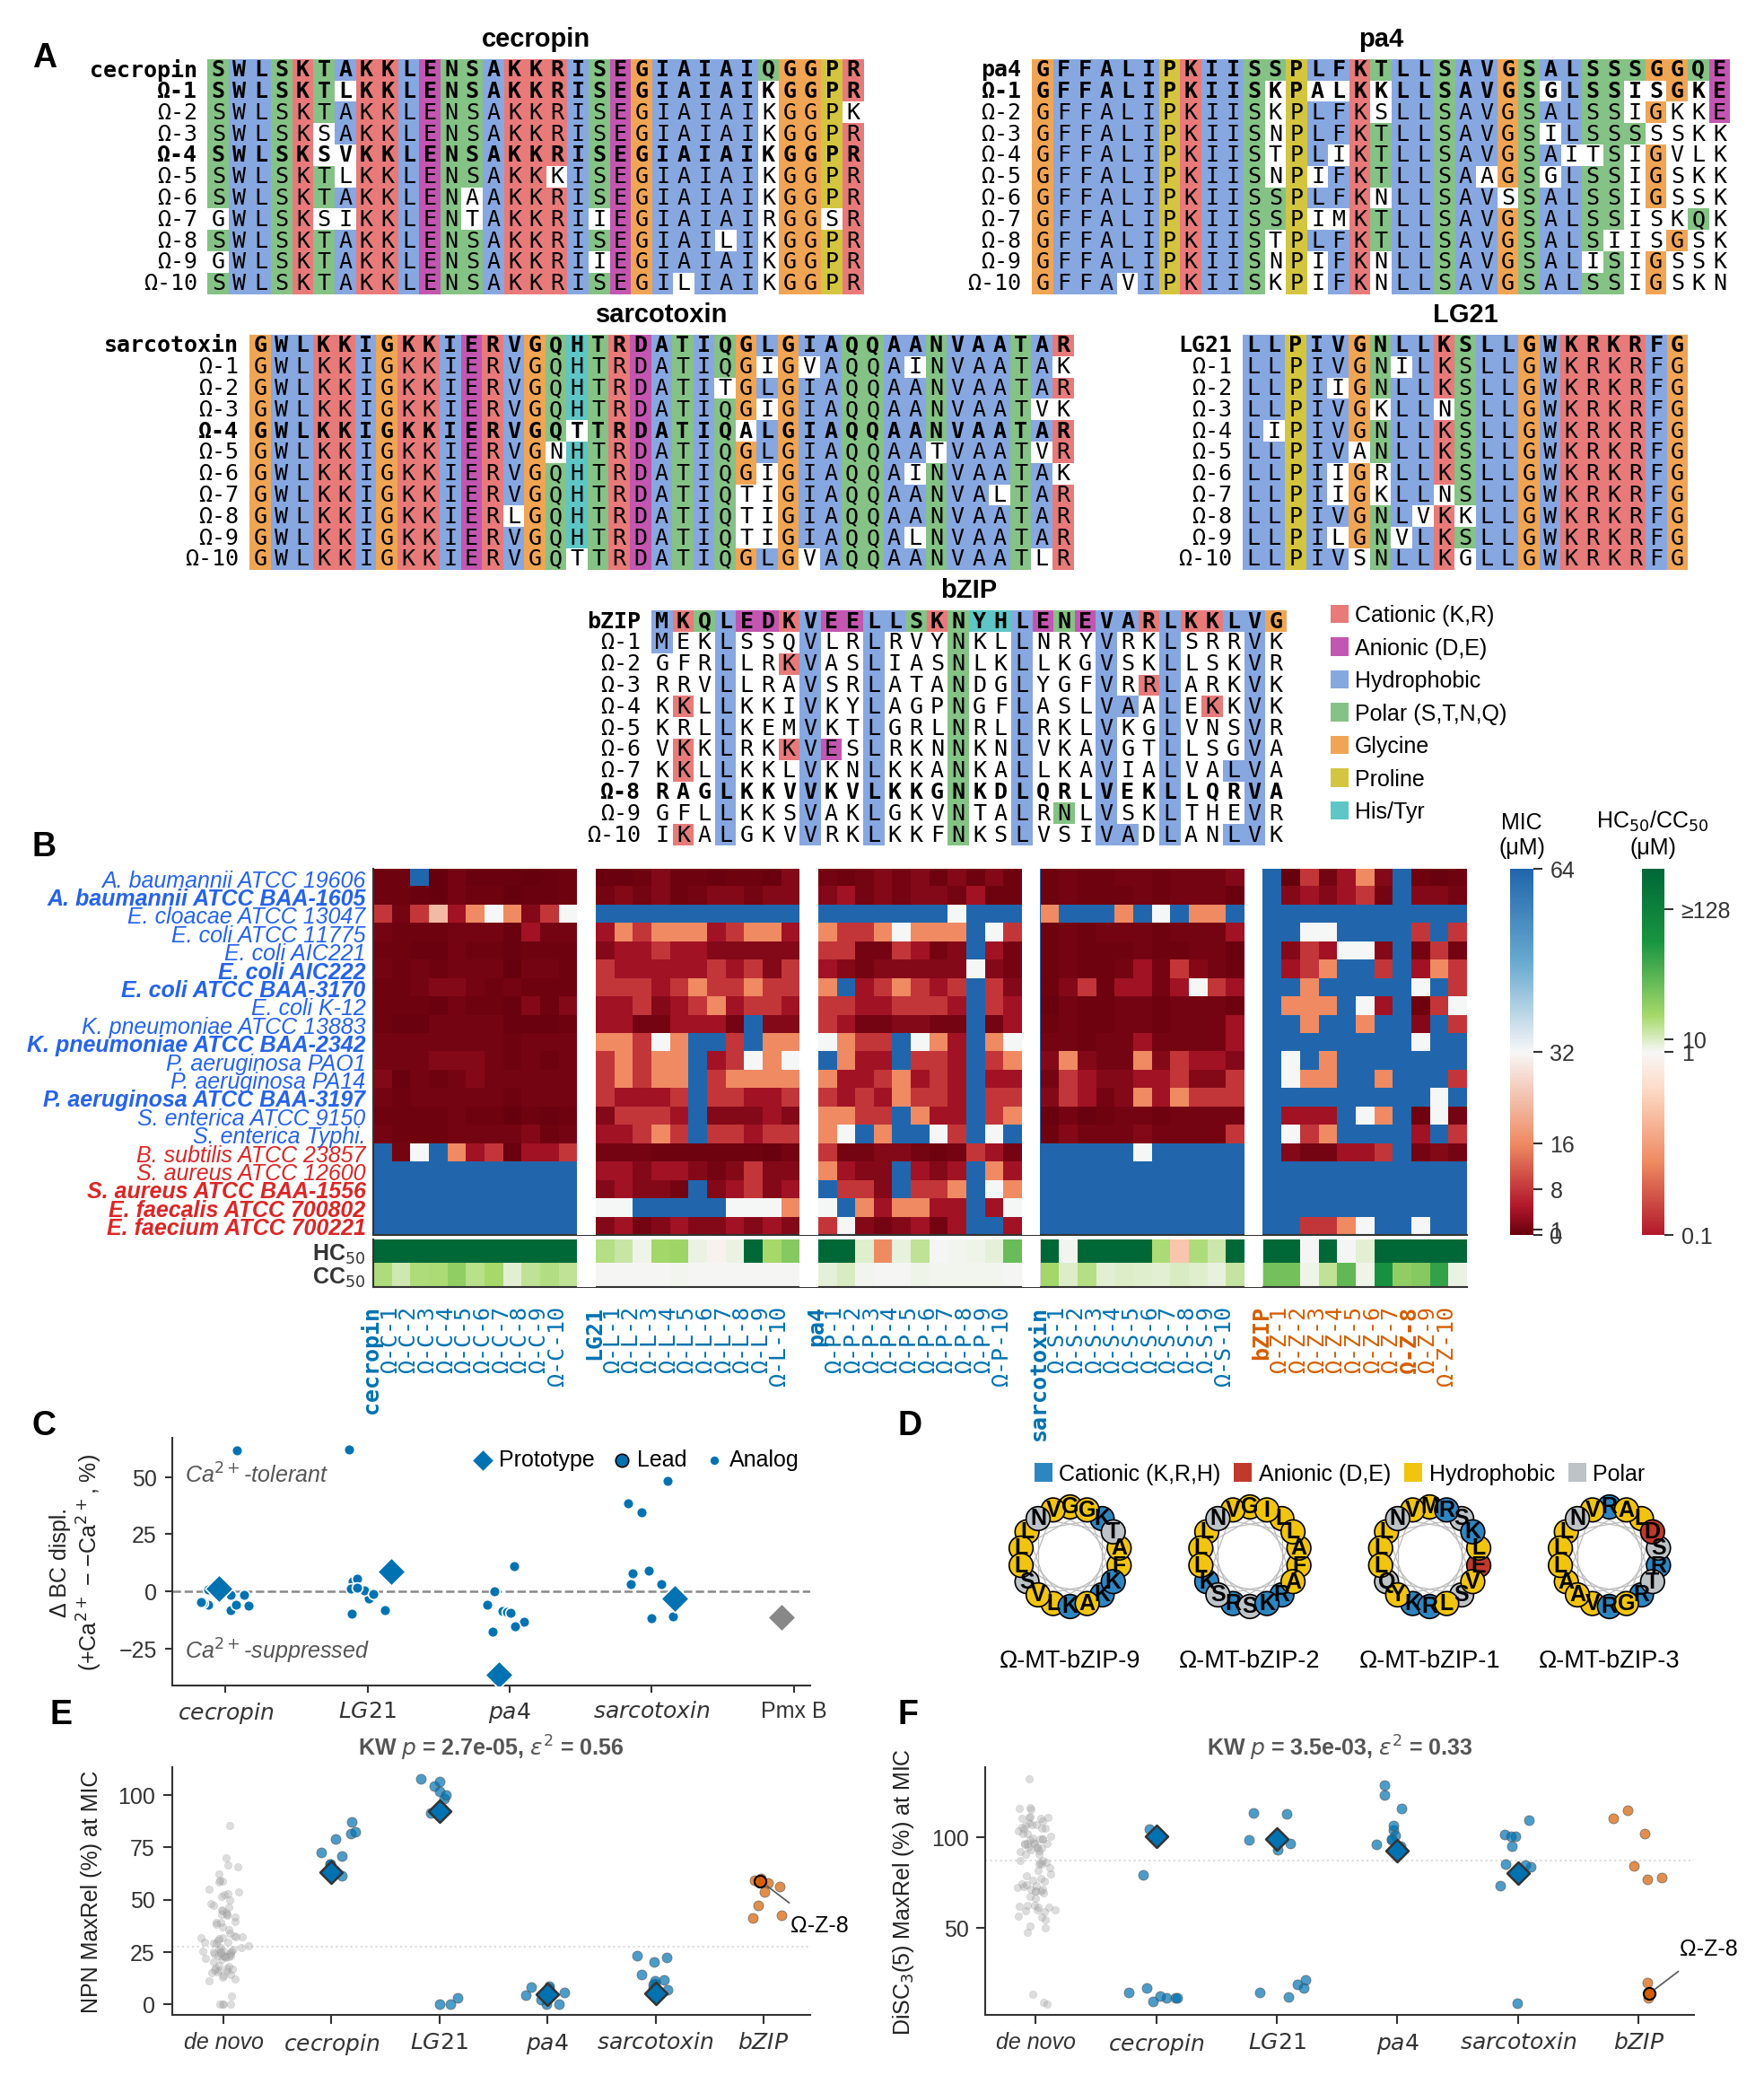

Saved figureS6_mechanism.


In [2]:
FIG_W, FIG_H = 6.5, 8.0
fig = plt.figure(figsize=(FIG_W, FIG_H))
PL = dict(fontsize=9, fontweight='bold', va='top', ha='left')

char_w=0.078; fw=char_w/FIG_W
char_h=0.055; fh=char_h/FIG_H
row_h=16*fh+0.008; gap=0.008

# ── Panel A: Sequence alignments ──────────────────────────────────────────────
A_TOP=0.978
wA_cec=(7+31+0.6)*fw; wA_pa4=(7+33+0.6)*fw
r1_w=wA_cec+gap+wA_pa4; r1_x=(1-r1_w)/2
y1=A_TOP-row_h
ax_cec=fig.add_axes([r1_x,y1,wA_cec,row_h])
ax_pa4=fig.add_axes([r1_x+wA_cec+gap,y1,wA_pa4,row_h])
wA_sar=(7+39+0.6)*fw; wA_lg=(7+21+0.6)*fw
r2_w=wA_sar+gap+wA_lg; r2_x=(1-r2_w)/2
y2=y1-row_h-0.010
ax_sar=fig.add_axes([r2_x,y2,wA_sar,row_h])
ax_lg=fig.add_axes([r2_x+wA_sar+gap,y2,wA_lg,row_h])
wA_bzip=(7+30+0.6)*fw
r3_x=(1-wA_bzip)/2
y3=y2-row_h-0.010
ax_bzip=fig.add_axes([r3_x,y3,wA_bzip,row_h])

for tname,ax in [('cecropin',ax_cec),('pa4',ax_pa4),('sarcotoxin',ax_sar),('LG21',ax_lg),('bZIP',ax_bzip)]:
    labs,seqs,bolds=get_family_sequences(tname)
    draw_alignment(ax,labs,seqs,bolds,tname,fontsize=6)
fig.text(0.005,A_TOP,'A',**PL)

leg_y=y3-0.020
aa_legend=[('Cationic (K,R)','#E87A7A'),('Anionic (D,E)','#C256B0'),('Hydrophobic','#87A7E0'),
           ('Polar (S,T,N,Q)','#85C285'),('Glycine','#F0A555'),('Proline','#D4C540'),('His/Tyr','#5EC6C6')]
handles=[Patch(facecolor=c,edgecolor='none',label=l) for l,c in aa_legend]
fig.legend(handles=handles,loc='upper left',bbox_to_anchor=(r3_x+wA_bzip+0.015, y3+row_h),
           ncol=1,fontsize=6,frameon=False,
           handletextpad=0.3,columnspacing=0.5,handlelength=0.8,handleheight=0.9,borderpad=0)

# ── Panel B ───────────────────────────────────────────────────────────────────
B_TOP=leg_y+0.010
# b_left/b_right keep panel B's strain labels and the HC50/CC50 colorbar inside
# the 6.5 in canvas (they sit outside the axes, so bbox_inches='tight' exports them)
B_MIC_H=0.170; b_left=0.20; b_right=0.825
B_MIC_BOT=B_TOP-B_MIC_H
B_TOX_TOP=B_MIC_BOT-0.002; B_TOX_H=0.022; B_TOX_BOT=B_TOX_TOP-B_TOX_H
ax_mic=fig.add_axes([b_left,B_MIC_BOT,b_right-b_left,B_MIC_H])
ax_tox=fig.add_axes([b_left,B_TOX_BOT,b_right-b_left,B_TOX_H])
cax_mic=fig.add_axes([b_right+0.025,B_MIC_BOT,0.013,B_MIC_H])
cax_tox=fig.add_axes([b_right+0.100,B_MIC_BOT,0.013,B_MIC_H])
draw_motif_heatmap(ax_mic,ax_tox,cax_mic,cax_tox)
fig.text(0.005,B_TOP+0.018,'B',**PL)

# f_left/g_right: panel C's two-line y-label and panel F's tick labels sit outside
# their axes; these margins keep the exported box inside 6.5 in.
f_left=0.085; f_right=0.45
g_left=0.55; g_right=0.955

# ── Panel C ──────────────────────────────────────────────────────────────────
C_TOP=B_TOX_BOT-0.070; C_H=0.115; C_BOT=C_TOP-C_H

ax_c=fig.add_axes([f_left, C_BOT, f_right-f_left, C_H])
draw_lps_delta(ax_c)
fig.text(0.005, C_TOP+0.013, 'C', **PL)

# ── Panel D: bZIP helical wheels (same row as C) ──────────────────────────────
_wheel_handles = [
    Patch(facecolor='#2E86C1', edgecolor='none', label='Cationic (K,R,H)'),
    Patch(facecolor='#C0392B', edgecolor='none', label='Anionic (D,E)'),
    Patch(facecolor='#F1C40F', edgecolor='none', label='Hydrophobic'),
    Patch(facecolor='#BDC3C7', edgecolor='none', label='Polar'),
]
fig.legend(handles=_wheel_handles,
           loc='lower center',
           bbox_to_anchor=((g_left + g_right) / 2, C_TOP - 0.027),
           ncol=4, fontsize=6, frameon=False,
           handletextpad=0.3, columnspacing=0.6, handlelength=0.8, handleheight=0.9, borderpad=0)

_n_wheels = len(BZIP_WHEEL_PANELS)
_wheel_gap = 0.006
_wheel_w = (g_right - g_left - (_n_wheels - 1) * _wheel_gap) / _n_wheels
for _wi, (_seq, _name) in enumerate(BZIP_WHEEL_PANELS):
    _ax_w = fig.add_axes([g_left + _wi * (_wheel_w + _wheel_gap), C_BOT, _wheel_w, C_H])
    helical_wheel(_seq, _name, _ax_w)
fig.text(g_left - 0.05, C_TOP+0.013, 'D', **PL)

# ── Panels E + F ──────────────────────────────────────────────────────────────
FG_TOP=C_BOT-0.038; FG_H=0.115; FG_BOT=FG_TOP-FG_H
ax_e=fig.add_axes([f_left,FG_BOT,f_right-f_left,FG_H])
ax_f=fig.add_axes([g_left,FG_BOT,g_right-g_left,FG_H])
draw_atmic_dotplot(ax_e,'NPN',LEAD_OFFSETS_F,'NPN MaxRel (%) at MIC')
draw_atmic_dotplot(ax_f,'DiSC',LEAD_OFFSETS_G,'DiSC$_3$(5) MaxRel (%) at MIC')
fig.text(f_left-0.07,FG_TOP+0.032,'E',**PL)
fig.text(g_left-0.05,FG_TOP+0.032,'F',**PL)

# Cell limits: exported box <= 6.5 x 8 in, every font >= 6 pt. bbox_inches='tight'
# grows past the canvas when an artist sits outside it, so check the real box.
fig.canvas.draw()
_tb = fig.get_tightbbox(fig.canvas.get_renderer())
print(f"  export box: {_tb.width:.2f} x {_tb.height:.2f} in "
      f"(x {_tb.x0:+.2f}..{_tb.x1:.2f}, y {_tb.y0:+.2f}..{_tb.y1:.2f}; Cell max 6.5 x 8)")

plt.savefig(OUT/'figureS6_mechanism.pdf',bbox_inches='tight', pad_inches=0.02)
plt.savefig(OUT/'figureS6_mechanism.svg',bbox_inches='tight', pad_inches=0.02)
plt.savefig(OUT/'figureS6_mechanism.png',dpi=400,bbox_inches='tight', pad_inches=0.02)
plt.show()
print('Saved figureS6_mechanism.')